<a href="https://colab.research.google.com/github/JelenaMaxVicovac/ml_final_task/blob/main/notebook/Jelena_Maksimovic_Vicovac_final_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Loading and inspecting the dataset

- loading csv file from GitHub
- checking number of rows and columns
- displaying the first few rows
- review data types and basic information

In [2]:
import pandas as pd

# load dataset from github
url="https://raw.githubusercontent.com/JelenaMaxVicovac/ml_final_task/main/data/IMLP4_TASK_03-products.csv"
df=pd.read_csv (url)

# data shape
print ("rows,columns:",df.shape)

# First five rows
print ("\nFirst five rows:")
print (df.head())

# Dataset info
print ("Dataset info:")
df.info()

rows,columns: (35311, 8)

First five rows:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/20

## Step 2: EDA

- checking missing values

Missing values per column:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


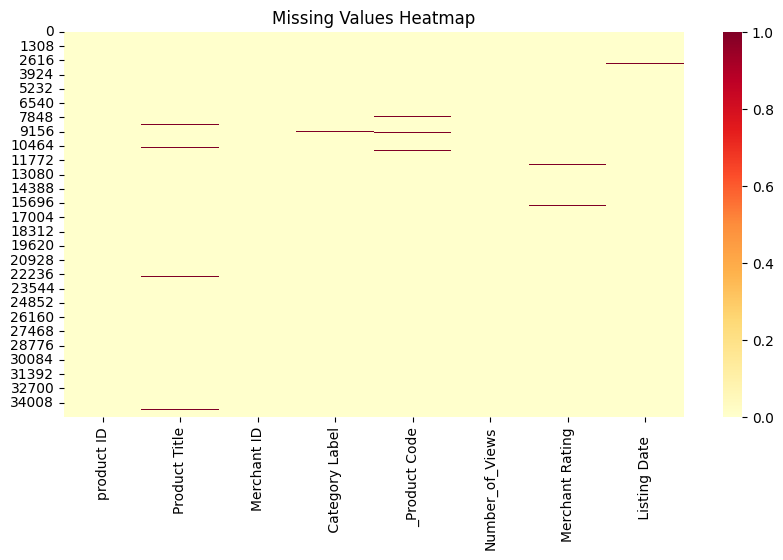

In [3]:
# Count missing values per column
print ("Missing values per column:")
print (df.isna().sum())

# Visualize missing data
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

The highest number of missing values is in the Product title and Merchant Rating columns.

## Checking column Category Label

In [4]:

# printing names of each column
print (df.columns)

# cleaning column names
df.columns = df.columns.str.strip()

# Count occurrences of each category label
category_counts = df['Category Label'].value_counts()

# Print counts
print("Category distribution (counts):")
print(category_counts)



Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='object')
Category distribution (counts):
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


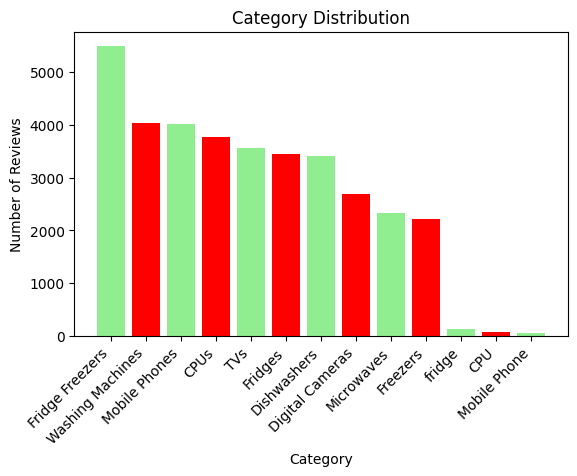

In [5]:
# Plot category distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(category_counts.index, category_counts.values, color=['lightgreen', 'red'])
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

## Checking column Product Title

In [16]:
# Data type of the 'Product Title' column
print("Data type of Product Title column:", df['Product Title'].dtype)

# First 10 values from the column
print("\nFirst 10 values in Product Title column:")
print(df['Product Title'].head(10))

# 20 most frequent values in the column
print("\nTop 20 most frequent values in Product Title column:")
print(df['Product Title'].value_counts().head(20))

# Check for known non-numeric text values
problematic_values = ['Not Available', 'N/A', 'None', '-', 'unknown', 'Unavailable']

# Identify rows with problematic values
mask_problematic = df['Product Title'].astype(str).str.strip().isin(problematic_values)
df_problematic = df[mask_problematic]
print(f"\nFound {len(df_problematic)} rows with problematic textual values:")
display(df_problematic[['Product Title']].drop_duplicates())

# identify wich values are not string
df['Product Title'].apply(type).value_counts()
mask = df['Product Title'].apply(lambda x: not isinstance(x, str))
df_non_strings = df[mask]
print("Number of values wich are not string:",len(df_non_strings))
print (df_non_strings)


Data type of Product Title column: object

First 10 values in Product Title column:
0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
5    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
6                 apple iphone 8 plus 64 gb space grey
7                  apple iphone 8 plus 64gb space grey
8                  apple iphone 8 plus 64gb space grey
9                  apple iphone 8 plus 64gb space grey
Name: Product Title, dtype: object

Top 20 most frequent values in Product Title column:
Product Title
washing machine                                                           90
built in fully integrated dishwasher                                      35
frost free fridge freezer                                                 34
washer dryer                    

,Product Title


Number of values wich are not string: 172
       product ID Product Title  Merchant ID Category Label _Product Code  \
172           173           NaN            1  Mobile Phones    GZ-3098-QU   
443           444           NaN           15  Mobile Phones    BE-1771-PE   
548           549           NaN            8  Mobile Phones    EH-6626-EA   
553           554           NaN            3  Mobile Phones    TA-4759-MR   
599           600           NaN           24  Mobile Phones    ND-9919-XI   
...           ...           ...          ...            ...           ...   
34429       46442           NaN          297        Fridges    TT-6246-EB   
34615       46636           NaN          298        Fridges    HU-2729-JQ   
34632       46653           NaN          297        Fridges    RB-0968-ZY   
34920       46948           NaN          119        Fridges    FV-2962-JM   
34985       47013           NaN          119        Fridges    NR-8035-HN   

       Number_of_Views  Merchant 

,count
Product Title,
<class 'str'>,35139
<class 'float'>,172


There are 172 float values, and 172 values wich are not string. Conclusion - All 172 problematic values are NaN.